### Table of Contents
#### 1. Project Overview
- Business context
- Dataset overview
- Project objectives
---
#### 2. Initial Data Exploration
- Load dataset into SQLite
- Schema inspection
- Data type review
- Initial row/column validation
---
#### 3. Data Quality Assessment
##### 3.1 Missing Value Assessment
- Missingness by column
- Missingness patterns
##### 3.2 Duplicate Transaction Validation
- Duplicate detection using:
  - `ParcelID`
  - `SaleDate`
  - `LegalReference`
##### 3.3 Sale Price Sanity Checks
- Extremely low transaction validation
- High-price outlier investigation
- Bulk transaction validation
##### 3.4 Year Built Validation
- Historical property review
- edge-case verification
##### 3.5 Categorical Value Validation
- `LandUse`
- `SoldAsVacant`
- `TaxDistrict`
##### 3.6 Bedroom/Bathroom Logic Validation
- Missing values
- impossible combinations
- extreme outlier validation
---
#### 4. Data Cleaning & Transformation
##### 4.1 Create Working Table
##### 4.2 Standardize Date Fields
#### 4.3 Handle Missing Property Addresses
##### 4.4 Standardize Categorical Fields
- `SoldAsVacant`
- `LandUse`
##### 4.5 Fix Data Types
- `YearBuilt`
- `Bedrooms`
- `FullBath`
- `HalfBath`
##### 4.6 Create Analytical Flags
- low-price transactions
- high-price outliers
- bed/bath logic issues
##### 4.7 Deduplicate Records
---
#### 5. Final Validation Checks
- Row count validation
- categorical validation
- anomaly flag validation
---
#### 6. Output
- Final cleaned dataset: `housing_final_cleaned`

### I. Import libraries, and connect to SQL database

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
# import xlsx file
file_name = "nashville_housing_data.xlsx"
df = pd.read_excel(file_name, sheet_name = "Sheet1", index_col=0)

In [4]:
df.head()

,ParcelID,LandUse,PropertyAddress,SaleDate,SalePrice,LegalReference,SoldAsVacant,OwnerName,OwnerAddress,Acreage,TaxDistrict,LandValue,BuildingValue,TotalValue,YearBuilt,Bedrooms,FullBath,HalfBath
UniqueID,,,,,,,,,,,,,,,,,,
2045,007 00 0 125.00,SINGLE FAMILY,"1808 FOX CHASE DR, GOODLETTSVILLE",2013-04-09,240000,20130412-0036474,No,"FRAZIER, CYRENTHA LYNETTE","1808 FOX CHASE DR, GOODLETTSVILLE, TN",2.3,GENERAL SERVICES DISTRICT,50000.0,168200.0,235700.0,1986.0,3.0,3.0,0.0
16918,007 00 0 130.00,SINGLE FAMILY,"1832 FOX CHASE DR, GOODLETTSVILLE",2014-06-10,366000,20140619-0053768,No,"BONER, CHARLES & LESLIE","1832 FOX CHASE DR, GOODLETTSVILLE, TN",3.5,GENERAL SERVICES DISTRICT,50000.0,264100.0,319000.0,1998.0,3.0,3.0,2.0
54582,007 00 0 138.00,SINGLE FAMILY,"1864 FOX CHASE DR, GOODLETTSVILLE",2016-09-26,435000,20160927-0101718,No,"WILSON, JAMES E. & JOANNE","1864 FOX CHASE DR, GOODLETTSVILLE, TN",2.9,GENERAL SERVICES DISTRICT,50000.0,216200.0,298000.0,1987.0,4.0,3.0,0.0
43070,007 00 0 143.00,SINGLE FAMILY,"1853 FOX CHASE DR, GOODLETTSVILLE",2016-01-29,255000,20160129-0008913,No,"BAKER, JAY K. & SUSAN E.","1853 FOX CHASE DR, GOODLETTSVILLE, TN",2.6,GENERAL SERVICES DISTRICT,50000.0,147300.0,197300.0,1985.0,3.0,3.0,0.0
22714,007 00 0 149.00,SINGLE FAMILY,"1829 FOX CHASE DR, GOODLETTSVILLE",2014-10-10,278000,20141015-0095255,No,"POST, CHRISTOPHER M. & SAMANTHA C.","1829 FOX CHASE DR, GOODLETTSVILLE, TN",2.0,GENERAL SERVICES DISTRICT,50000.0,152300.0,202300.0,1984.0,4.0,3.0,0.0


In [5]:
# connect to SQL database
conn = sqlite3.connect('my_projects.db')
df.to_sql("housing", conn, if_exists='replace', index=False)

56477

In [6]:
# schema overview
print("The dataset's dimension:", df.shape, "\n")
print("The datatypes of columns:\n", df.dtypes)

The dataset's dimension: (56477, 18) 

The datatypes of columns:
 ParcelID                      str
LandUse                       str
PropertyAddress               str
SaleDate           datetime64[us]
SalePrice                   int64
LegalReference             object
SoldAsVacant                  str
OwnerName                     str
OwnerAddress                  str
Acreage                   float64
TaxDistrict                   str
LandValue                 float64
BuildingValue             float64
TotalValue                float64
YearBuilt                 float64
Bedrooms                  float64
FullBath                  float64
HalfBath                  float64
dtype: object


### II. Exploratory Analysis with Data Quality Assessment

#### 2.1 Percentage of null values per column & number of records affected

In [7]:
columns = df.columns.tolist()
queries = []
for col in columns:
    query = f"""SELECT '{col}' AS column_name,
                        COUNT(*) AS total_rows,
                        SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS null_count,
                        ROUND(100.0* SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS null_pct
                FROM housing"""
    queries.append(query)
final_query = " UNION ALL ".join(queries)
null_summary_df = pd.read_sql_query(final_query, conn)
null_summary_df.sort_values(by="null_pct", ascending=False)

,column_name,total_rows,null_count,null_pct
17,HalfBath,56477,32333,57.25
15,Bedrooms,56477,32320,57.23
14,YearBuilt,56477,32314,57.22
16,FullBath,56477,32202,57.02
7,OwnerName,56477,31216,55.27
10,TaxDistrict,56477,30462,53.94
13,TotalValue,56477,30462,53.94
12,BuildingValue,56477,30462,53.94
11,LandValue,56477,30462,53.94
9,Acreage,56477,30462,53.94


#### **Observations**: 
1. This dataset splits into tiers of data quality:
    - Tier 1: Reliable core transaction data (0% missing):
      - `ParcelID`
      - `SaleDate`
      - `SalePrice`
      - `LegalReference`
      - `SoldAsVacant`
      - `LandUse`
    - Tier 2: Moderately missing but imputable (only 0.05% missing, i.e. 29 affected observations):
      - `PropertyAddress`
    - Tier 3: High missingness features (~ 54% to 57%):
      - `HalfBath`
      - `Bedrooms`
      - `YearBuilt`
      - `FullBath`
      - `OwnerName`
      - `TaxDistrict`
      - `TotalValue`
      - `BuildingValue`
      - `LandValue`
      - `Acreage`
      - `OwnerAddress`
2. Several features have exactly the same null count of 30462, which may suggest a data dependency issue:
   - These fields are likely come from the same secondary data source and are missing together.
       - `Acreage`
       - `LandValue`
       - `BuildingValue`
       - `TotalValue`
       - `TaxDistrict`
       - `OwnerAddress`

#### **Interpretations**: 
- This dataset is transaction-centric, not property-detail centric:
  -  Most transaction-related fields are complete, while property and owner fields are highly incomplete.
  -  `PropertyAddress` is nearly complete (<0.1% missingness), so it can be safely used for geographic segmentation after minor imputation.
  -  Property-related attributes contain >54% missingness, limiting their use to subset-based analysis and requiring careful interpretation when used in pricing comparisons.

#### **Decision**:
- Due to these patterns, core pricing trend analysis will rely on transaction-centric features, while property-related insights will be derived from filtered subsets.

#### 2.2 Duplicates check

In [8]:
# any duplicate transactions ?
pd.read_sql_query(
    """SELECT 
           ParcelID, 
           SaleDate, 
           LegalReference, 
           COUNT(*) AS dup_rows
       FROM housing 
       GROUP BY
           ParcelID, 
           SaleDate, 
           LegalReference 
       HAVING COUNT(*)>1""", 
    conn)

,ParcelID,SaleDate,LegalReference,dup_rows
0,081 02 0 144.00,2015-02-02 00:00:00,20150205-0010843,2
1,081 07 0 265.00,2015-02-17 00:00:00,20150223-0015122,2
2,081 10 0 313.00,2015-02-20 00:00:00,20150224-0015904,2
3,081 11 0 168.00,2015-02-13 00:00:00,20150218-0013602,2
4,081 11 0 495.00,2015-02-09 00:00:00,20150210-0012450,2
...,...,...,...,...
99,175 06 0A 026.00,2014-02-03 00:00:00,20140205-0010116,2
100,175 06 0A 121.00,2015-02-10 00:00:00,20150213-0013533,2
101,176 01 0 017.00,2015-02-13 00:00:00,20150220-0014969,2
102,176 01 0A 104.00,2015-02-20 00:00:00,20150226-0016625,2


In [9]:
# if all dup_rows=2 ?
pd.read_sql_query(
    """SELECT 
           COUNT(*) AS num_groups, 
           dup_rows
       FROM (
           SELECT
               ParcelID, 
               SaleDate, 
               LegalReference, 
               COUNT(*) AS dup_rows
           FROM housing 
           GROUP BY 
               ParcelID, 
               SaleDate, 
               LegalReference 
           HAVING COUNT(*)>1)
        GROUP BY dup_rows
        ORDER BY dup_rows""", 
    conn)

,num_groups,dup_rows
0,104,2


#### **Observations**: 
- Duplicate transactions were checked using the combination of `ParcelID` (i.e. property identifier), `SaleDate` (i.e. transaction time), and `LegalReference` (i.e. official record); if all match, it is highly unlikely to be two legitimate different transactions.
  - A total of 104 duplicate groups were identified, with all duplicate groups having exactly 2 identical records;
  - No higher-order duplications (e.g. 3+ repeated records) were observed.

#### **Interpretations**:
- Under normal circumstances, a property cannot be legitimately sold multiple times at the same time under the same legal reference, these duplicate records are highly unlikely to represent valid multiple transactions.
- The clear pattern of duplicates occurring strictly in pairs suggests a systematic, non-random duplication issue:
  - This issue is likely caused by duplicate data ingestion, unintended join duplication, or repeated data entry.

#### **Decision:**
- These records can be treated as redundant duplicates, and will be handled through deduplication during the data cleaning step.

#### 2.3 Sanity check: negative / zero / unrealistic sale prices

In [10]:
# any negative / zero / unrealistically low sale prices ?
pd.read_sql_query(
    """SELECT 
           ParcelID, 
           SalePrice,
           SaleDate, 
           PropertyAddress, 
           LegalReference
       FROM housing
       WHERE SalePrice < 10000
       ORDER BY 
           SalePrice, 
           SaleDate""",
    conn)

,ParcelID,SalePrice,SaleDate,PropertyAddress,LegalReference
0,081 11 0 466.00,50,2013-03-15 00:00:00,"0 WHELESS ST, NASHVILLE",20130320-0027369
1,041 11 0 011.00,100,2013-01-04 00:00:00,"4021 DUMBARTON DR, NASHVILLE",20130129-0009438
2,070 05 0 031.00,100,2013-10-15 00:00:00,"2415 STIVERS ST, NASHVILLE",20131016-0108113
3,091 04 0 050.00,500,2014-03-10 00:00:00,"0 40TH AVE N, NASHVILLE",20140403-0027813
4,070 08 0 061.00,750,2016-03-22 00:00:00,"0 W TRINITY LN, NASHVILLE",20160323-0027506
...,...,...,...,...,...
89,092 06 0 590.00,9500,2013-08-29 00:00:00,"729 26TH AVE N, NASHVILLE",20130904-0092912
90,162 03 0 125.00,9500,2014-05-29 00:00:00,"304 BART DR, ANTIOCH",20140529-0046273
91,071 05 0 096.00,9500,2015-03-03 00:00:00,"0 HAYNES ST, NASHVILLE",20150309-0019732
92,071 05 0 097.00,9500,2015-03-03 00:00:00,"0 HAYNES ST, NASHVILLE",20150309-0019733


In [11]:
# low sale prices distribution
## standard deviation was computed using mathematical formula due to SQLite limitations
pd.read_sql_query(
    """SELECT 
           MIN(SalePrice) AS min_price, 
           MAX(SalePrice) AS max_price,
           AVG(SalePrice) AS avg_price,
           ROUND(SQRT(AVG(SalePrice * SalePrice) - AVG(SalePrice)*AVG(SalePrice)), 2) AS std_price
       FROM housing
       WHERE SalePrice < 10000""",
    conn)

,min_price,max_price,avg_price,std_price
0,50,9794,5365.914894,2920.67


In [12]:
# group by LandUse for further analysis
pd.read_sql_query(
    """SELECT 
           LandUse,
           COUNT(*) AS low_price_count,
           MIN(SalePrice) AS min_low_price,
           ROUND(AVG(SalePrice), 2) AS avg_low_price,
           MAX(SalePrice) AS max_low_price
       FROM housing
       WHERE SalePrice < 10000
       GROUP BY LandUse
       ORDER BY low_price_count DESC""",
    conn)

,LandUse,low_price_count,min_low_price,avg_low_price,max_low_price
0,VACANT RES LAND,39,50,5559.08,9794
1,VACANT RESIDENTIAL LAND,36,750,5094.22,9500
2,SINGLE FAMILY,12,100,4645.83,8500
3,RESIDENTIAL CONDO,4,5750,7562.50,9000
4,RESIDENTIAL COMBO/MISC,2,3000,5100.00,7200
5,TRIPLEX,1,8000,8000.00,8000


In [13]:
# top 3 lowest sale prices for different LandUse
pd.read_sql_query(
    """WITH lowest_3_prices AS (
           SELECT 
               ParcelID,
               LandUse,
               SalePrice,
               SaleDate,
               PropertyAddress,
               ROW_NUMBER() OVER (PARTITION BY LandUse ORDER BY SalePrice ASC) AS lowest_rank
           FROM housing
           WHERE 
               SalePrice < 10000)
       SELECT *
       FROM lowest_3_prices
       WHERE lowest_rank <= 3
       ORDER BY LandUse, SalePrice""",
    conn)

,ParcelID,LandUse,SalePrice,SaleDate,PropertyAddress,lowest_rank
0,091 10 0 154.00,RESIDENTIAL COMBO/MISC,3000,2013-06-18 00:00:00,"5812 A ROBERTSON AVE, NASHVILLE",1
1,081 07 0 189.00,RESIDENTIAL COMBO/MISC,7200,2014-10-22 00:00:00,"1719 ST LOUIS ST, NASHVILLE",2
2,133 16 0A 088.00,RESIDENTIAL CONDO,5750,2015-10-20 00:00:00,"270 TAMPA DR, NASHVILLE",1
3,133 16 0A 181.00,RESIDENTIAL CONDO,7000,2013-10-04 00:00:00,"270 TAMPA DR, NASHVILLE",2
4,090 11 0A 016.00,RESIDENTIAL CONDO,8500,2013-07-26 00:00:00,"515 BASSWOOD AVE, NASHVILLE",3
5,041 11 0 011.00,SINGLE FAMILY,100,2013-01-04 00:00:00,"4021 DUMBARTON DR, NASHVILLE",1
6,070 05 0 031.00,SINGLE FAMILY,100,2013-10-15 00:00:00,"2415 STIVERS ST, NASHVILLE",2
7,083 13 0 143.00,SINGLE FAMILY,800,2016-09-09 00:00:00,"1228 LILLIAN ST, NASHVILLE",3
8,081 11 0 370.00,TRIPLEX,8000,2013-08-13 00:00:00,"1604 16TH AVE N, NASHVILLE",1
9,081 11 0 466.00,VACANT RES LAND,50,2013-03-15 00:00:00,"0 WHELESS ST, NASHVILLE",1


#### **Observations**:
- A total of 94 transactions (0.17% of the dataset) have `SalePrice` less than \\$10,000, with the lowest sale price at \\$50.
  - This subset has mean ≈ \\$5,366, with standard deviation ≈ \\$2,921, indicating a wide spread.
  - These low-price transactions are not randomly distributed:
    - 75 out of 94 transactions (80%) belong to:
      - `VACANT RES LAND`: 39
      - `VACANT RESIDENTIAL LAND`: 36
    - The remaining 19 transactions (20%) belong to residential property categories:
      - `SINGLE FAMILY`: 12
      - `RESIDENTIAL CONDO`: 4
      - `RESIDENTIAL COMBO/MISC`: 2
      - `TRIPLEX`: 1
	- Within residential categories, several transactions have extremely low prices (e.g., \\$100), which are inconsistent with typical market sales.


#### **Interpretations**:
- Initially, extremely low sale prices may appear to be data errors; however, the strong clustering within vacant land categories indicates that these records are likely legitimate but non-market transactions.
  - These non-market transactions are likely be:
    - land-only transfers
    - intra-family transfers
    - ownership adjustments
    - administrative or legal transactions
    - etc.
- The presence of low-price transactions within residential property categories further indicates that:
  - not all recorded transactions reflect open-market conditions
- Furthermore, a spot-check against the official [***Nashville county records***](https://portal.padctn.org/OFS/WP/Home) indicates that at least these top 3 lowest price transactions are genuine recorded transfers rather than simple data-entry errors.

#### **Decision**:
- These low-value transactions will be retained in the dataset for completeness.
- However, transactions with `SalePrice` less than \\$10,000 will be excluded from core pricing analysis as they are unlikely to represent market-driven property valuations.

#### 2.3 Sanity check: invalid YearBuilt

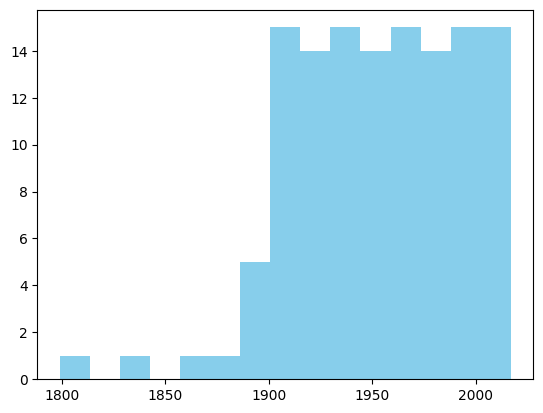

In [14]:
year_built_df = pd.read_sql_query(
    """SELECT DISTINCT YearBuilt FROM housing""", conn)

plt.hist(year_built_df['YearBuilt'], bins=15, color='skyblue')
plt.show()

In [15]:
pd.read_sql_query(
    """SELECT
           ParcelID,
           YearBuilt,
           PropertyAddress,
           LandUse
       FROM housing
       WHERE YearBuilt <= 1850""", 
    conn)

,ParcelID,YearBuilt,PropertyAddress,LandUse
0,073 09 0 109.00,1799.0,"1833 WELCOME LN, NASHVILLE",SPLIT CLASS
1,095 03 0 008.00,1832.0,"2250 LEBANON PIKE, NASHVILLE",SINGLE FAMILY


#### **Observations**:
- The distribution of `YearBuilt` shows a clear concentration after 1850, with a small number of earlier values:
  - Only 2 records have `YearBuilt` < 1850, specifically 1799 and 1832.

#### **Interpretations**:
- These `YearBuilt` values fall outside the main distribution and are considered edge cases.
  - Given the historical context of the dataset, such values are uncommon but not inherently invalid.
- Thus, a spot-check of these records against against the official [***Nashville county records***](https://portal.padctn.org/OFS/WP/Home) suggests that they are legitimate historical properties, rather than data-entry errors.

#### **Decision**:
- These records are retained in the dataset as valid observations:
  - However, their rarity is noted for context.

#### 2.4 Sanity check: inconsistent categorical values

In [16]:
# LandUse: inconsistent categorical values?
pd.read_sql_query(
    """SELECT LandUse, COUNT(*) as count
       FROM housing
       GROUP BY LandUse
       ORDER BY LandUse, count DESC""",
    conn)

## VACANT RESIDENTIAL LAND / VACANT RES LAND / VACANT RESIENTIAL LAND
## GREENBELT / GREENBELT/RES_x000D_\nGRRENBELT/RES

,LandUse,count
0,APARTMENT: LOW RISE (BUILT SINCE 1960),2
1,CHURCH,34
2,CLUB/UNION HALL/LODGE,1
3,CONDO,247
4,CONDOMINIUM OFC OR OTHER COM CONDO,35
5,CONVENIENCE MARKET WITHOUT GAS,1
6,DAY CARE CENTER,2
7,DORMITORY/BOARDING HOUSE,19
8,DUPLEX,1373
9,FOREST,10


In [17]:
# SoldAsVacant & TaxDistrict: inconsistent categorical values?
pd.read_sql_query(
    """SELECT 'SoldAsVacant' AS col_name, SoldAsVacant, COUNT(*) AS count
       FROM housing
       GROUP BY SoldAsVacant
       
       UNION ALL
       
       SELECT 'TaxDistrict', TaxDistrict, COUNT(*)
       FROM housing
       GROUP BY TaxDistrict

       ORDER BY col_name, count DESC""",
    conn)

## SoldAsVacant: No / N, Yes / Y

,col_name,SoldAsVacant,count
0,SoldAsVacant,No,51403
1,SoldAsVacant,Yes,4623
2,SoldAsVacant,N,399
3,SoldAsVacant,Y,52
4,TaxDistrict,NaN,30462
5,TaxDistrict,URBAN SERVICES DISTRICT,20024
6,TaxDistrict,GENERAL SERVICES DISTRICT,4556
7,TaxDistrict,CITY OF FOREST HILLS,407
8,TaxDistrict,CITY OF OAK HILL,393
9,TaxDistrict,CITY OF GOODLETTSVILLE,379


#### **Observations**:
- Categorical value inspection was performed on `LandUse`, `SoldAsVacant`, and `TaxDistrict`:
  - High-cardinality identifiers such as `ParcelID`, `PropertyAddress`, `LegalReference`, `OwnerName`, and `OwnerAddress` were excluded, as their uniqueness makes categorical consistency test less meaningful.
- The `LandUse` feature contains a wide range of categories representing different property types. Most categories appear consistent, however, a small number of categories show inconsistent naming patterns, including:
  - Variations of *vacant residential land*:
    - abbreviations: `VACANT RESIDENTIAL LAND` vs `VACANT RES LAND`
    - typo error: `VACANT RESIENTIAL LAND`
  - Variations of *greenbelt*:
    - encoding artifact: `GREENBELT` vs `GREENBELT/RES_x000D_\nGRRENBELT/RES`
- The `SoldAsVacant` feature also contains inconsistent categorical values mostly caused by abbreviations(such as `N` vs `No`, `Y` vs `Yes`)

#### **Interpretations**:
- Despite differences in formatting, these inconsistencies appeared in `LandUse` and `SoldAsVacant` are likely represent the same underlying categories rather than distinct classifications. 

#### **Decision**:
- Thus, these inconsistencies will be addressed during the data cleaning step in order to avoid fragment category counts or distort aggregation results.

#### 2.5 Sanity check: impossible bed / bath combinations

In [18]:
pd.read_sql_query(
    """SELECT 
           LandUse,
           COUNT(*) AS total_records,
           SUM(CASE WHEN Bedrooms IS NULL OR FullBath IS NULL OR HalfBath IS NULL 
               THEN 1 ELSE 0 END) AS records_with_any_missing_bed_bath,
           SUM(CASE WHEN Bedrooms IS NOT NULL AND FullBath IS NOT NULL AND HalfBath IS NOT NULL 
               THEN 1 ELSE 0 END) AS complete_bed_bath_records
       FROM housing
       GROUP BY LandUse
       ORDER BY records_with_any_missing_bed_bath DESC""", 
    conn)

,LandUse,total_records,records_with_any_missing_bed_bath,complete_bed_bath_records
0,RESIDENTIAL CONDO,14080,14080,0
1,SINGLE FAMILY,34197,12913,21284
2,VACANT RESIDENTIAL LAND,3547,3291,256
3,VACANT RES LAND,1549,1320,229
4,CONDO,247,247,0
5,ZERO LOT LINE,1048,203,845
6,DUPLEX,1373,189,1184
7,RESIDENTIAL COMBO/MISC,95,59,36
8,CONDOMINIUM OFC OR OTHER COM CONDO,35,35,0
9,MOBILE HOME,20,18,2


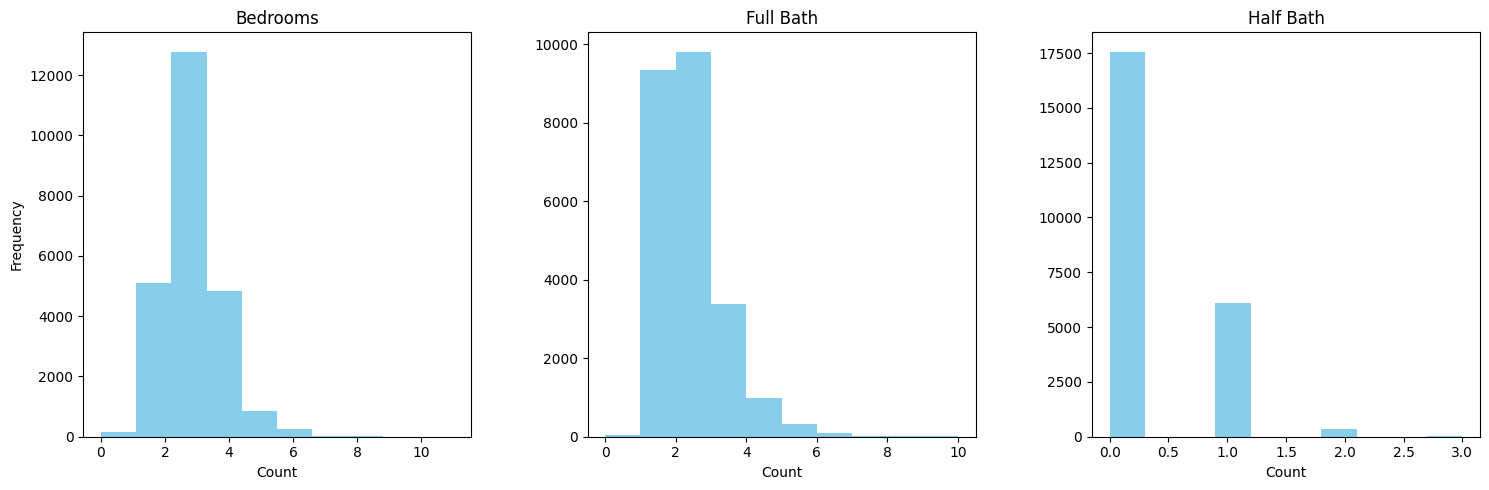

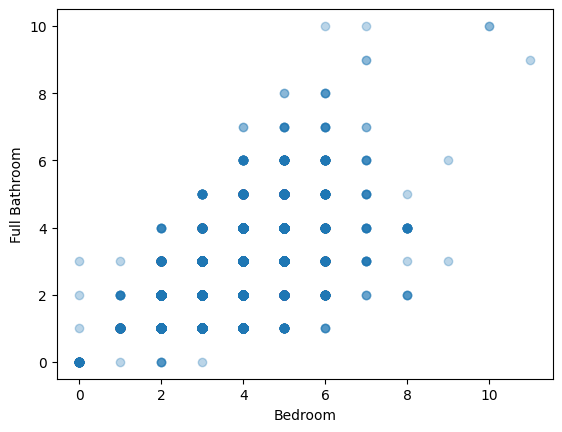

In [19]:
# only evaluate on non-null subset
bed_bath_notnull_df = pd.read_sql_query(
    """SELECT *
       FROM housing
       WHERE Bedrooms IS NOT NULL
           AND FullBath IS NOT NULL
           AND HalfBath IS NOT NULL""",
    conn)

# distributions for Bedrooms, FullBath, HalfBath
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Bedrooms
axes[0].hist(bed_bath_notnull_df["Bedrooms"], bins=10, color='skyblue')
axes[0].set_title("Bedrooms")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
# FullBath
axes[1].hist(bed_bath_notnull_df["FullBath"], bins=10, color='skyblue')
axes[1].set_title("Full Bath")
axes[1].set_xlabel("Count")
# HalfBath
axes[2].hist(bed_bath_notnull_df["HalfBath"], bins=10, color='skyblue')
axes[2].set_title("Half Bath")
axes[2].set_xlabel("Count")
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

# Bedrooms vs. FullBath
plt.scatter(bed_bath_notnull_df['Bedrooms'], bed_bath_notnull_df['FullBath'], alpha=0.3)
plt.xlabel("Bedroom")
plt.ylabel("Full Bathroom")
plt.show()

In [20]:
bed_bath_notnull_df.to_sql("bed_bath_notnull", conn, if_exists="replace", index=False)
pd.read_sql_query(
    """SELECT
           MIN(Bedrooms) AS min_bedroom,
           ROUND(AVG(Bedrooms), 2) AS avg_bedroom, 
           MAX(Bedrooms) AS max_bedroom,
           MIN(FullBath) AS min_fullbath,
           ROUND(AVG(FullBath), 2) AS avg_fullbath,
           MAX(FullBath) AS max_fullbath,
           MIN(HalfBath) AS min_halfbath,
           ROUND(AVG(HalfBath), 2) AS avg_halfbath,
           MAX(HalfBath) AS max_halfbath
       FROM bed_bath_notnull""", 
    conn)

,min_bedroom,avg_bedroom,max_bedroom,min_fullbath,avg_fullbath,max_fullbath,min_halfbath,avg_halfbath,max_halfbath
0,0.0,3.09,11.0,0.0,1.89,10.0,0.0,0.29,3.0


In [21]:
# scenario 1: Bedroom = 0 while FullBath / HalfBath > 0
pd.read_sql_query(
    """SELECT
           ParcelID,
           Bedrooms,
           FullBath,
           HalfBath,
           LandUse,
           YearBuilt
       FROM bed_bath_notnull
       WHERE Bedrooms = 0
           AND (FullBath > 0 OR HalfBath > 0)""",
    conn)

,ParcelID,Bedrooms,FullBath,HalfBath,LandUse,YearBuilt
0,070 06 0 041.00,0.0,1.0,0.0,SINGLE FAMILY,1940.0
1,082 09 0 254.00,0.0,3.0,0.0,OFFICE BLDG (ONE OR TWO STORIES),1910.0
2,145 10 0 048.00,0.0,2.0,1.0,CHURCH,1960.0


In [22]:
# scenario 2: multi-bedroom house with no bathroom
pd.read_sql_query(
    """SELECT
           ParcelID,
           Bedrooms,
           FullBath,
           HalfBath,
           LandUse,
           YearBuilt
       FROM bed_bath_notnull
       WHERE Bedrooms >= 3 AND FullBath < 1""",
    conn)

,ParcelID,Bedrooms,FullBath,HalfBath,LandUse,YearBuilt
0,081 02 0 136.00,3.0,0.0,0.0,SINGLE FAMILY,1910.0


In [23]:
# scenario 3: bedroom vs bathroom ratio anomalies
## total_bath = FullBath + HalfBath, then check if total_bath > Bedrooms + 2
pd.read_sql_query(
    """SELECT
           DISTINCT ParcelID,
           Bedrooms,
           FullBath,
           HalfBath,
           LandUse,
           YearBuilt
       FROM bed_bath_notnull
       WHERE FullBath + 0.5 * HalfBath > Bedrooms + 2""",
    conn)

,ParcelID,Bedrooms,FullBath,HalfBath,LandUse,YearBuilt
0,082 09 0 254.00,0.0,3.0,0.0,OFFICE BLDG (ONE OR TWO STORIES),1910.0
1,103 13 0 005.00,3.0,5.0,1.0,SINGLE FAMILY,1955.0
2,116 10 0 102.00,3.0,5.0,1.0,SINGLE FAMILY,1920.0
3,116 11 0 002.00,5.0,7.0,1.0,SINGLE FAMILY,1937.0
4,116 14 0 132.00,6.0,10.0,1.0,SINGLE FAMILY,1970.0
5,116 15 0 022.00,5.0,6.0,3.0,SINGLE FAMILY,1988.0
6,130 03 0 002.00,4.0,7.0,0.0,SINGLE FAMILY,1958.0
7,130 03 0 122.00,5.0,8.0,0.0,SINGLE FAMILY,1990.0
8,130 07 0 014.00,5.0,8.0,0.0,SINGLE FAMILY,1930.0
9,130 14 0 048.00,4.0,6.0,1.0,SINGLE FAMILY,1984.0


In [24]:
# scenario 4: extreme outliers
pd.read_sql_query(
    """SELECT
           DISTINCT ParcelID,
           Bedrooms,
           FullBath,
           HalfBath,
           LandUse,
           YearBuilt
       FROM bed_bath_notnull
       WHERE Bedrooms > 8 OR FullBath > 6""",
    conn)

,ParcelID,Bedrooms,FullBath,HalfBath,LandUse,YearBuilt
0,081 11 0 574.00,7.0,7.0,0.0,SINGLE FAMILY,2014.0
1,082 07 0 406.00,9.0,6.0,0.0,QUADPLEX,1964.0
2,083 09 0 295.00,9.0,3.0,1.0,SINGLE FAMILY,1925.0
3,102 15 0 102.00,6.0,7.0,1.0,SINGLE FAMILY,2017.0
4,103 09 0 104.00,6.0,8.0,0.0,SINGLE FAMILY,1955.0
5,115 12 0 038.00,6.0,7.0,2.0,SINGLE FAMILY,2008.0
6,116 02 0 010.00,7.0,9.0,0.0,SINGLE FAMILY,1935.0
7,116 06 0 010.00,6.0,7.0,0.0,SINGLE FAMILY,1948.0
8,116 07 0 076.00,5.0,7.0,0.0,SINGLE FAMILY,1991.0
9,116 07 0 089.00,6.0,7.0,0.0,SINGLE FAMILY,1968.0


#### **Observations**:
- The bedroom versus bathroom combination check mainly focuses on residential properties, as bedrooms and bathrooms counts are less meaningful for non-residential properties.
- Overall distributions show that most houses have:
  - ~ 3 bedrooms, 1-2 full bathrooms, and 0-1 half bathroom, which aligns with typical residential patterns.
- The scatter plot confirms a general positive relationship between bedrooms and bathrooms, with a small number of anomalies deviating from this pattern.
- Logical validation checks identified anomalies across the following scenarios:
  - Scenario 1: 0 Bedroom with bathrooms
    - 3 records identified, with 2 from non-residential categories and are irrelevant
    - 1 residential record identified as anomaly
  - Scenario 2: multi-bedroom house with 0 bathroom
    - 1 residential record identified as anomaly
  - Scenario 3: high bath-to-bedroom ratio
    - 12 records identified, with 2 from non-residential categories and are irrelevant
    - 10 residential records with unusual high bathroom counts relative to bedrooms
  - Scenario 4: extreme outliers
    - 28 records identified, with 1 from non-residential category and is irrelevant
    - 27 residential records with high bedroom counts (>8) or high bathroom counts (>6)
 
#### **Interpretations**:
- The majority of records align with expected real-world housing patterns, indicating the `Bedrooms`, `FullBath`, and `HalfBath` features are generally reliable.
- Scenario 1 & 2 indicate true logical inconsistencies, and are most likely caused by data entry errors or misrecorded values.
- Scenario 3 & 4 do not necessarily indicate data errors:
  - high bathroom-to-bedroom ratios and extreme high counts are likely occur in large or luxury properties
  - these records form the upper tail of the distribution rather than systematic issues.
- Non-residential properties (e.g. `OFFICE`, `CHURCH`, `VACANT LAND`, etc.) introduce noise in this validation process, as these attributes are not directly comparable to residential properties.
  
#### **Decision**:
- Restrict to residential properties when performing downstream analysis for bedrooms versus bathrooms relationships:
  - Exclude the 2 residential records with clear logical inconsistencies in Scenario 1 & 2 from analyses involving bed/bath relationships.
    - filtering will be applied only within specific analytical contexts, while all original records in the dataset will be preserved
  - Retain residential records with high bath-to-bedroom ratios and extreme values in Scenario 3 & 4, as they represent valid but rare edge cases in the real housing market.
- Overall, `Bedrooms`, `FullBath`, and `HalfBath` features are reliable for analysis after minor rule-based filtering.

#### 2.6 Sanity check:  outlier sale prices

In [25]:
# compute quartiles
pd.read_sql_query(
    """WITH saleprice_quartiles AS (
           SELECT
               SalePrice,
               NTILE(4) OVER (ORDER BY SalePrice) AS quartile
           FROM housing
           WHERE SalePrice IS NOT NULL)
       
       SELECT
           quartile,
           MIN(SalePrice) AS min_price,
           MAX(SalePrice) AS max_price
       FROM saleprice_quartiles
       GROUP BY quartile
       ORDER BY quartile""",
    conn)

,quartile,min_price,max_price
0,1,50,135000
1,2,135000,205100
2,3,205225,328500
3,4,328700,54278060


In [26]:
# quartiles w/ outlier bounds
pd.read_sql_query(
    """WITH price_stats AS (
           SELECT
               SalePrice,
               NTILE(4) OVER (ORDER BY SalePrice) AS quartile
           FROM housing
           WHERE SalePrice IS NOT NULL),
       
       quartiles AS (
           SELECT
               MAX(CASE WHEN quartile = 1 THEN SalePrice END) AS q1,
               MAX(CASE WHEN quartile = 3 THEN SalePrice END) AS q3
           FROM price_stats),

       bounds AS (
           SELECT
               q1,
               q3,
               (q3 - q1) AS iqr,
               q1 - 1.5 * (q3 - q1) AS lower_bound,
               q3 + 1.5 * (q3 - q1) AS upper_bound
           FROM quartiles)

       SELECT
           COUNT(*) AS outlier_count,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM housing), 2) AS outliers_pecentage,
           MIN(SalePrice) AS min_outlier_price,
           MAX(SalePrice) AS max_outlier_price
       FROM housing h
       CROSS JOIN bounds b
       WHERE h.SalePrice < b.lower_bound
           OR h.SalePrice > b.upper_bound""", 
    conn)

,outlier_count,outliers_pecentage,min_outlier_price,max_outlier_price
0,4161,7.37,619000,54278060


In [27]:
# repeated high-price transactions? if yes -> likely bulk / multi-unit transactions
pd.read_sql_query(
    """SELECT 
           SalePrice, 
           COUNT(*) AS transaction_counts
       FROM housing
       WHERE SalePrice >= 619000
       GROUP BY SalePrice
       HAVING COUNT(*) > 1
       ORDER BY SalePrice DESC
       LIMIT 20""",
    conn)

,SalePrice,transaction_counts
0,54278060,7
1,14100000,23
2,13156000,92
3,12350000,2
4,9500000,6
5,5491000,30
6,5000000,3
7,4700000,47
8,4614550,11
9,4400000,24


In [28]:
# multi-parcel transactions?
pd.read_sql_query(
    """SELECT
           SaleDate,
           PropertyAddress,
           LegalReference,
           SalePrice,
           COUNT(DISTINCT ParcelID) AS parcel_counts,
           LandUse
       FROM housing
       WHERE SalePrice >= 619000
       GROUP BY SaleDate, PropertyAddress, LegalReference, SalePrice
       HAVING COUNT(DISTINCT ParcelID) > 1
       ORDER BY SalePrice DESC, parcel_counts DESC""", 
    conn)

,SaleDate,PropertyAddress,LegalReference,SalePrice,parcel_counts,LandUse
0,2014-12-17 00:00:00,"320 11TH AVE S, NASHVILLE",20141217-0115478,54278060,7,RESIDENTIAL CONDO
1,2014-11-04 00:00:00,"6680 CHARLOTTE PIKE, NASHVILLE",20141104-0101953,4700000,47,RESIDENTIAL CONDO
2,2016-10-05 00:00:00,"6813 CHARLOTTE PIKE, NASHVILLE",20161006-0105745,4614550,6,RESIDENTIAL CONDO
3,2015-09-29 00:00:00,"0 35TH AVE N, NASHVILLE",20151002-0100496,4400000,3,VACANT RESIDENTIAL LAND
4,2015-09-29 00:00:00,"0 DELAWARE AVE, NASHVILLE",20151002-0100496,4400000,3,VACANT RESIDENTIAL LAND
5,2015-12-21 00:00:00,"6901 LENOX VILLAGE DR, NASHVILLE",20151223-0129198,4000000,27,CONDOMINIUM OFC OR OTHER COM CONDO
6,2015-03-17 00:00:00,"2003 CONVENT PL, NASHVILLE",20150318-0023247,2665500,6,QUADPLEX
7,2014-05-30 00:00:00,"162 4TH AVE N, NASHVILLE",20140530-0046587,2114481,9,CONDO
8,2015-11-19 00:00:00,"1110 W TRINITY LN, NASHVILLE",20151130-0120429,2040000,3,SINGLE FAMILY
9,2013-06-17 00:00:00,"0 GLEN ECHO RD, NASHVILLE",20130618-0062083,2000000,5,VACANT RES LAND


#### **Observations**:
- Quartile analysis indicate a strong right-skewed distribution in `SalePrice`:
  - Q1: \\$50 -- \\$135,000
  - Q2: \\$135,000 -- \\$205,100
  - Q3: \\$205,225 -- \\$328,500
  - Q4: \\$328,700 -- \\$54,278,060
    - the upper quartile spans a very wide range, suggesting large variation in high-end transactions
- 4,161 records (~ 7.37%) were identified as high-price outliers using the IQR method, with a lower bound of ≈ \\$619,000
  - Many high-price transactions are repeated across multiple records:
    - e.g. \\$54.3M (7 records), \\$13.1M (92 records), etc.
  - These repeated high-price transactions often share the same `SaleDate`, `PropertyAddress`, and `LegalReference` and involve multiple `ParcelID` under the same transaction
  - These patterns are observed across multiple property types such as `RESIDENTIAL CONDO`, `CONDO`, and `VACANT LAND`

#### **Interpretations**:
- `SalePrice` in the dataset contains a long right tail, which is expected in real estate markets with a mix of standard and high-value transactions:
  - The high-value transactions are more likely to be statistical outliers than data errors
  - Repeated high-price transactions across multiple `ParcelID` are more likley due to bulk transaction or multi-unit property sales (e.g. condo developments)
  - These high-value transactions are structurelly different from standard property sales and can significantly inflat aggregate metrics (e.g. average sale prices), but should not be treated as data quality issues.


#### **Decision**:
- All high-price outlier records will be retained in the dataset as they represent valid transactions.
- Median sale price should be used as the primary metric for typical property pricing analysis, since it is less sensitive to extreme values:
  - However, average sale price will be used as a complementary metric to capture overall market value
- Potential multi-parcel or bulk transactions will be flagged or separately analyzed to avoid distortion.

### ***Summary***:
Certain property-level features (e.g., bedrooms, bathrooms) are missing for a significant portion of records. Analysis involving these fields is restricted to a filtered subset, while broader pricing trends rely on more complete variables such as SalePrice, YearBuilt, and location.

- **Key Findings**:
  - The Nashville housing dataset contains 56,000+ records with a mix of residential and non-residential properties.
  - Several features show high missingness (54% to 57%), primarily driven by non-residential property types.
  - 104 duplicate groups were identified, all occurring in pairs, indicating a systematic duplication issue.
  - Sale price distribution is heavily right-skewed, with ~ 7% of transactions flagged as high-value outliers using the IQR method.
  - 31 records of high-price transactions represents multi-parcel or bulk sales, rather than individual property transactions.
  - Minor inconsistencies were observed in categorical features (e.g., `LandUse`, `SoldAsVacant`), likely due to data entry issues.
- **Implications**:
  - Not all features are equally reliable across property types; context-aware filtering is required.
  - Raw averages (e.g., average sale price) may be distorted by high-value transactions, requiring more robust metrics.
  - Certain anomalies (e.g., bed/bath inconsistencies) represent true data errors, while others (e.g., extreme prices) reflect valid but uncommon cases.
  - The dataset is suitable for analysis after targeted cleaning and feature standardization, rather than aggressive data removal.
- **Next Step**:
  - Standardize categorical values
  - Handle duplicates
  - Resolve logical inconsistencies
  - Prepare analysis-ready features

### III. Data Cleaning & Transformation

#### 3.1 Create a working copy and preserve the original dataset

In [29]:
conn.execute("DROP TABLE IF EXISTS housing_copy")
conn.execute(
    """CREATE TABLE housing_copy AS
           SELECT *
           FROM housing""")
conn.commit()

#### 3.2 Standardize `SaleDate`

In [30]:
# verify time component in SaleDate
pd.read_sql_query(
    """SELECT
           SUBSTR(SaleDate, 12) AS time_part,
           COUNT(*) AS count
       FROM housing_copy
       GROUP BY time_part""", 
    conn)
## all records have identical time component, so time information carries no analytical value

,time_part,count
0,00:00:00,56477


In [31]:
# convert SaleDate to a DATE feature
conn.execute(
    """UPDATE housing_copy
       SET SaleDate = DATE(SaleDate)""")
conn.commit()

*Note:*
- SQLite stores dates flexibly as TEXT/NUM/REAL depending on implementation. SaleDate was standardized to date-only format for analytical consistency.

#### 3.3 Fill missing `PropertyAddress` using other rows with the same `ParcelID`

In [32]:
# validation check for conflicting PropertyAddress
pd.read_sql_query(
    """SELECT
           ParcelID,
           COUNT(DISTINCT PropertyAddress) AS distinct_address_count
       FROM housing_copy
       WHERE PropertyAddress IS NOT NULL
       GROUP BY ParcelID
       HAVING COUNT(DISTINCT PropertyAddress) > 1
       ORDER BY distinct_address_count DESC""", 
    conn)

,ParcelID,distinct_address_count
0,163 07 0A 104.00,3
1,130 16 0 076.00,3
2,119 16 0 062.00,3
3,091 06 0 238.00,3
4,082 04 0 025.00,3
...,...,...
2036,025 04 0 126.00,2
2037,025 04 0 016.00,2
2038,018 08 0 015.00,2
2039,018 07 0 150.00,2


In [33]:
# create a mapping table
conn.execute("DROP TABLE IF EXISTS parcel_address_map")
conn.execute(
    """CREATE TABLE parcel_address_map AS
           SELECT
               ParcelID,
               MIN(PropertyAddress) AS mapped_property_address
           FROM housing_copy
           WHERE PropertyAddress IS NOT NULL
           GROUP BY ParcelID
           HAVING COUNT(DISTINCT PropertyAddress)=1""")
conn.commit()

In [34]:
# update only safely mappable missing PropertyAddress
conn.execute("""
    UPDATE housing_copy
    SET PropertyAddress = (
        SELECT mapped_property_address
        FROM parcel_address_map
        WHERE parcel_address_map.ParcelID = housing_copy.ParcelID)
    WHERE PropertyAddress IS NULL
      AND ParcelID IN (
          SELECT ParcelID
          FROM parcel_address_map)""")
conn.commit()

#### 3.4 Standardize `SoldAsVacant`

In [35]:
conn.execute("""
    UPDATE housing_copy
    SET SoldAsVacant =
        CASE
            WHEN SoldAsVacant = 'Y' THEN 'Yes'
            WHEN SoldAsVacant = 'N' THEN 'No'
            ELSE SoldAsVacant
        END""")
conn.commit()

#### 3.5 Standardize `LandUse`

In [36]:
# add a new column
conn.execute("""
    ALTER TABLE housing_copy
    ADD COLUMN LandUse_cleaned TEXT""")
conn.commit()

In [37]:
# fix typos, abbreviations, encoding while preserving original `LandUse`
conn.execute("""
    UPDATE housing_copy
    SET LandUse_cleaned =
        CASE
            WHEN TRIM(LandUse) IN (
                'VACANT RES LAND',
                'VACANT RESIDENTIAL LAND',
                'VACANT RESIENTIAL LAND'
            )
                THEN 'VACANT RESIDENTIAL LAND'
            WHEN TRIM(LandUse) LIKE 'GREENBELT%'
                THEN 'GREENBELT'
            ELSE TRIM(LandUse)
        END""")
conn.commit()

#### 3.6 Convert `YearBuilt`, `Bedrooms`, `FullBath`, `HalfBath` to integers

In [38]:
conn.execute("DROP TABLE IF EXISTS housing_cleaned")
conn.execute("""
    CREATE TABLE housing_cleaned AS
    SELECT
        ParcelID,
        LandUse AS LandUse_raw,
        LandUse_cleaned AS LandUse,
        PropertyAddress,
        SaleDate,
        CAST(SalePrice AS INTEGER) AS SalePrice,
        LegalReference,
        SoldAsVacant,
        OwnerName,
        OwnerAddress,
        Acreage,
        TaxDistrict,
        LandValue,
        BuildingValue,
        TotalValue,
        CAST(YearBuilt AS INTEGER) AS YearBuilt,
        CAST(Bedrooms AS INTEGER) AS Bedrooms,
        CAST(FullBath AS INTEGER) AS FullBath,
        CAST(HalfBath AS INTEGER) AS HalfBath
    FROM housing_copy""")
conn.commit()

#### 3.7 Add analysis flags

In [39]:
conn.execute("""
    ALTER TABLE housing_cleaned
    ADD COLUMN is_low_price_transaction INTEGER
""")
conn.execute("""
    UPDATE housing_cleaned
    SET is_low_price_transaction =
        CASE WHEN SalePrice < 10000 THEN 1 ELSE 0 END""")
conn.commit()

In [40]:
conn.execute("""
    ALTER TABLE housing_cleaned
    ADD COLUMN is_high_price_outlier INTEGER
""")
conn.execute("""
    UPDATE housing_cleaned
    SET is_high_price_outlier =
        CASE WHEN SalePrice >= 619000 THEN 1 ELSE 0 END""")
conn.commit()

In [41]:
conn.execute("""
    ALTER TABLE housing_cleaned
    ADD COLUMN is_bed_bath_logic_issue INTEGER
""")
conn.execute("""
    UPDATE housing_cleaned
    SET is_bed_bath_logic_issue =
        CASE
            WHEN Bedrooms = 0 AND (FullBath > 0 OR HalfBath > 0) THEN 1
            WHEN Bedrooms >= 3 AND FullBath = 0 AND HalfBath = 0 THEN 1
            ELSE 0
        END""")
conn.commit()

#### 3.8 Create a final table with duplicate-free transactions

In [42]:
# remove systematic duplicate transactions while keeping the first row
conn.execute("DROP TABLE IF EXISTS housing_final")
conn.execute("""
    CREATE TABLE housing_final AS
    SELECT *
    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY ParcelID, SaleDate, LegalReference
                ORDER BY rowid
            ) AS duplicate_rank
        FROM housing_cleaned)
    WHERE duplicate_rank = 1""")
conn.commit()

*Note*: 
- Transaction uniqueness was enforced using: `ParcelID` + `SaleDate` + `LegalReference`
- 104 Duplicate records were removed by retaining the first SQLite row within each duplicated `ParcelID` + `SaleDate` + `LegalReference` group using ROW_NUMBER logic

#### 3.9 Final validation checks

In [43]:
pd.read_sql_query("""
    SELECT COUNT(*) AS final_row_count
    FROM housing_final
""", conn)

,final_row_count
0,56373


In [44]:
pd.read_sql_query("""
    SELECT SoldAsVacant, COUNT(*) AS count
    FROM housing_final
    GROUP BY SoldAsVacant
""", conn)

,SoldAsVacant,count
0,No,51704
1,Yes,4669


In [45]:
pd.read_sql_query("""
    SELECT LandUse, COUNT(*) AS count
    FROM housing_final
    GROUP BY LandUse
    ORDER BY count DESC
""", conn)

,LandUse,count
0,SINGLE FAMILY,34120
1,RESIDENTIAL CONDO,14064
2,VACANT RESIDENTIAL LAND,5091
3,DUPLEX,1372
4,ZERO LOT LINE,1047
5,CONDO,247
6,RESIDENTIAL COMBO/MISC,95
7,TRIPLEX,92
8,QUADPLEX,39
9,CONDOMINIUM OFC OR OTHER COM CONDO,35


In [46]:
pd.read_sql_query("""
    SELECT
        SUM(is_low_price_transaction) AS low_price_transactions,
        SUM(is_high_price_outlier) AS high_price_outliers,
        SUM(is_bed_bath_logic_issue) AS bed_bath_logic_issues
    FROM housing_final
""", conn)

,low_price_transactions,high_price_outliers,bed_bath_logic_issues
0,94,4161,4


### ***Summary***

#### **Observations:**
- 104 duplicate records were identified and removed
- Missing `PropertyAddress` values were selectively filled using only unambiguous `ParcelID` mappings
- `SoldAsVacant` were standardized into binary categories (Yes/No)
- Inconsistent `LandUse` labels were consolidated
- Numeric housing features were converted into analysis-ready formats
- Low-price transactions, luxury sales, and bed/bath anomalies were flagged rather than removed

#### **Interpretation:**
- Most quality issues were structural
- The dataset largely reflects legitimate real estate complexity, including:
  - bulk transactions
  - luxury sales
  - vacant land transfers
  - rare property configurations

#### **Final Decision:**
- Remove only confirmed duplicates
- Standardize inconsistent values
- Preserve legitimate market edge cases
- Create an analysis-ready dataset while maintaining real-world transaction complexity

### IV. Export Cleaned Table

In [47]:
housing_final_df = pd.read_sql_query("""SELECT * FROM housing_final""", conn)

housing_final_df.to_csv("housing_final_cleaned.csv", index=False)